In [80]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from scipy.stats import zscore
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score,recall_score,f1_score, classification_report
from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt


In [61]:
#load the dataset 
data = pd.read_csv('diabetesDataset.csv')
data.head()

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years),Diabete (y/n)
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [76]:
sum=data['Diabete (y/n)'].value_counts()
print(sum)

Diabete (y/n)
0    461
1    227
Name: count, dtype: int64


In [63]:
#check for missing values
print("Missing values per column:")
data.isnull().sum()


Missing values per column:


Number of times pregnant                                                    0
Plasma glucose concentration a 2 hours in an oral glucose tolerance test    0
Diastolic blood pressure (mm Hg)                                            0
Triceps skin fold thickness (mm)                                            0
2-Hour serum insulin (mu U/ml)                                              0
Body mass index (weight in kg/(height in m)^2)                              0
Diabetes pedigree function                                                  0
Age (years)                                                                 0
Diabete (y/n)                                                               0
dtype: int64

In [64]:
z_scores= np.abs(zscore(data.select_dtypes(include=[np.number])))
data=data[(z_scores < 3).all(axis=1)]


In [65]:
#seperate attributes from labels 
x=data.drop(columns=['Diabete (y/n)'])
y=data['Diabete (y/n)']
y


0      1
1      0
2      1
3      0
5      0
      ..
763    0
764    0
765    0
766    1
767    0
Name: Diabete (y/n), Length: 688, dtype: int64

In [66]:
#feature scaling
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [67]:
#split the dataset
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

In [68]:
#train a decision tree classifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)
dt_acc = dt.score(x_test, y_test)


In [69]:
dt_acc

0.7028985507246377

In [70]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)
rf_acc = rf.score(x_test, y_test)


In [71]:
rf_acc

0.7318840579710145

In [72]:
xgb_model=XGBClassifier()
xgb_model.fit(x_train, y_train)
y_pred_xgb = xgb_model.predict(x_test)
xgb_acc = xgb_model.score(x_test, y_test)
xgb_acc

0.717391304347826

In [73]:
#train a neural network
nn = Sequential([
    Dense(16, activation='relu', input_shape=(x_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])
nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
nn.fit(x_train, y_train, epochs=50, batch_size=16, verbose=0)

nn_loss, nn_acc = nn.evaluate(x_test, y_test, verbose=0)
nn_acc

/Users/ajdoubleag/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


0.7463768124580383

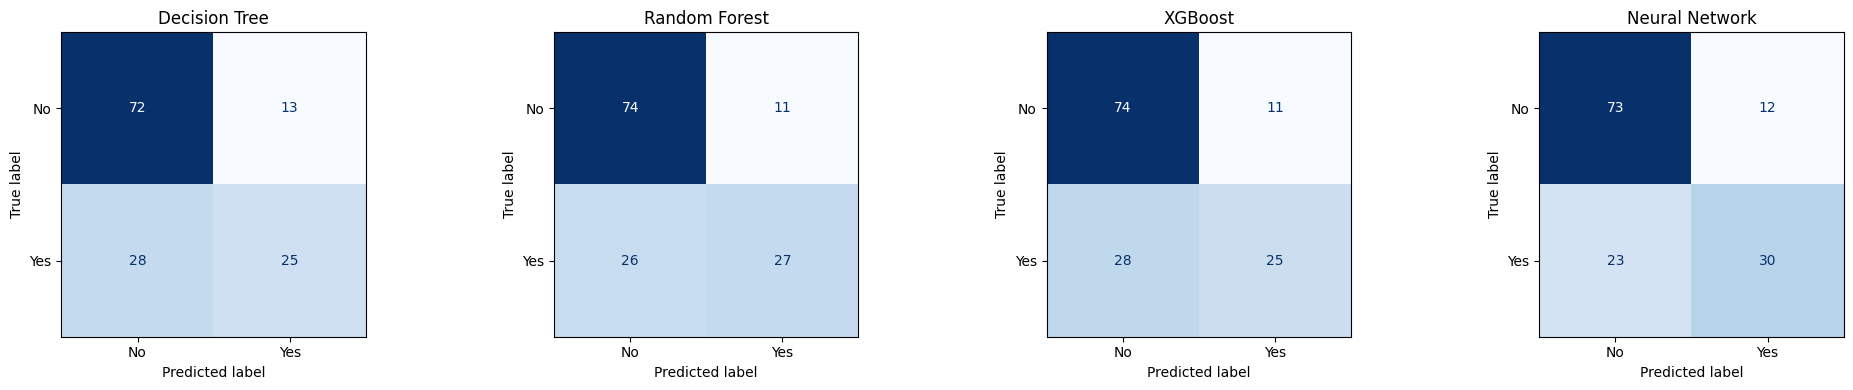

In [74]:
#confusion matrices for all classifiers
models = {
    'Decision Tree': dt,
    'Random Forest': rf,
    'XGBoost': xgb_model,
    'Neural Network': nn
}

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, model) in zip(axes, models.items()):
    if name == 'Neural Network':
        y_pred = (model.predict(x_test, verbose=0) > 0.5).astype(int).flatten()
    else:
        y_pred = model.predict(x_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}')
plt.tight_layout()
plt.show()

In [ ]:
print(classification_report(y_test, dt.predict(x_test)))

              precision    recall  f1-score   support

           0       0.72      0.85      0.78        85
           1       0.66      0.47      0.55        53

    accuracy                           0.70       138
   macro avg       0.69      0.66      0.66       138
weighted avg       0.70      0.70      0.69       138

